In [2]:
import sys
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    project_root = cwd.parent
else:
    project_root = cwd

sys.path.insert(0, str(project_root))

figure_dir = project_root / "figures"
figure_dir.mkdir(exist_ok=True)

print("Project root:", project_root)

Project root: /Users/amber/derivatives-pricing-calibration


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from src.models.black_scholes import call_price
from src.pricing.monte_carlo import (
    simulate_terminal_prices,
    monte_carlo_price,
    monte_carlo_price_antithetic,
)

# Monte Carlo Option Pricing

This notebook studies Monte Carlo pricing of European options under the
risk-neutral geometric Brownian motion model.

The objectives are:

- simulate terminal stock prices;
- estimate European call option prices;
- compare Monte Carlo prices with the Black-Scholes analytical solution;
- investigate Monte Carlo convergence;
- evaluate antithetic variates as a variance-reduction technique.

## 1. Terminal Stock Price Distribution

Under the risk-neutral measure, the stock price follows

$$
S_T
=
S_0
\exp
\left[
\left(r-\frac{1}{2}\sigma^2\right)T
+
\sigma\sqrt{T}Z
\right],
\qquad
Z\sim N(0,1).
$$

Therefore, the terminal stock price follows a lognormal distribution.

In [14]:
S0 = 100
K = 100
T = 1
r = 0.05
sigma = 0.20

n_paths = 100_000
seed = 42

In [15]:
ST = simulate_terminal_prices(
    S0=S0,
    T=T,
    r=r,
    sigma=sigma,
    n_paths=n_paths,
    seed=seed,
)

print("Number of simulations:", len(ST))
print("Mean terminal price:", np.mean(ST))
print("Median terminal price:", np.median(ST))
print("Minimum terminal price:", np.min(ST))
print("Maximum terminal price:", np.max(ST))

Number of simulations: 100000
Mean terminal price: 105.05486606908605
Median terminal price: 102.86006178688633
Minimum terminal price: 42.834646338528145
Maximum terminal price: 280.512204093185


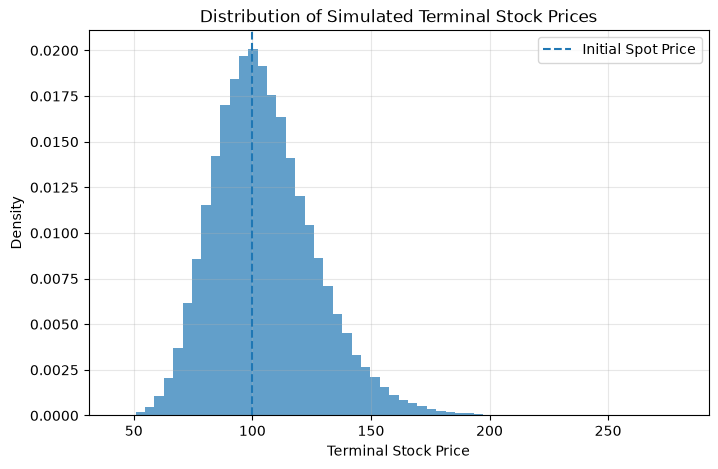

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(
    ST,
    bins=60,
    density=True,
    alpha=0.7
)

plt.axvline(
    S0,
    linestyle="--",
    label="Initial Spot Price"
)

plt.xlabel("Terminal Stock Price")
plt.ylabel("Density")
plt.title("Distribution of Simulated Terminal Stock Prices")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    figure_dir / "terminal_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2. Monte Carlo Price vs Black-Scholes

Under the risk-neutral measure, the value of a European call option is the discounted expected payoff:

$$
C_0
=
e^{-rT}
\mathbb{E}^{\mathbb{Q}}
\left[
(S_T-K)^+
\right]
$$

where

$$
(S_T-K)^+
=
\max(S_T-K,0)
$$

Monte Carlo simulation approximates this expectation using a finite number of simulated terminal stock prices:

$$
\hat{C}_N
=
e^{-rT}
\frac{1}{N}
\sum_{i=1}^{N}
\max
\left(
S_T^{(i)}-K,
0
\right)
$$

As the number of simulations $N$ increases, the Monte Carlo estimate should approach the Black-Scholes analytical price:

$$
\hat{C}_N
\rightarrow
C_{\mathrm{BS}}
$$

In [17]:
mc_price, mc_se = monte_carlo_price(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    option_type="call",
    n_paths=100_000,
    seed=42,
)

bs_price = call_price(
    S0,
    K,
    T,
    r,
    sigma,
)

print("Black-Scholes Price:", bs_price)
print("Monte Carlo Price:", mc_price)
print("Monte Carlo Standard Error:", mc_se)
print("Absolute Error:", abs(mc_price - bs_price))

Black-Scholes Price: 10.450583572185565
Monte Carlo Price: 10.420541193153113
Monte Carlo Standard Error: 0.046769902520818175
Absolute Error: 0.03004237903245155


## 3. Monte Carlo Standard Error and Confidence Interval

Monte Carlo pricing is based on random sampling, so the estimated option price is not exactly equal to the true value.

The standard error of the Monte Carlo estimator is approximately

$$
SE(\hat{V}_N)
=
\frac{s}{\sqrt{N}}
$$

where $s$ is the sample standard deviation of the discounted payoffs and $N$ is the number of simulations.

An approximate 95% confidence interval is

$$
\hat{V}_N
\pm
1.96\,SE(\hat{V}_N)
$$

or equivalently,

$$
CI_{95\%}
=
\left[
\hat{V}_N - 1.96\,SE,
\;
\hat{V}_N + 1.96\,SE
\right]
$$

If the Black-Scholes analytical price lies inside this interval, the Monte Carlo result is consistent with the analytical benchmark within sampling error.

In [18]:
lower = mc_price - 1.96 * mc_se
upper = mc_price + 1.96 * mc_se

print("Monte Carlo Price:", mc_price)
print("Standard Error:", mc_se)
print("95% Confidence Interval:", (lower, upper))
print("Black-Scholes Price:", bs_price)

print(
    "Black-Scholes inside CI:",
    lower <= bs_price <= upper
)

Monte Carlo Price: 10.420541193153113
Standard Error: 0.046769902520818175
95% Confidence Interval: (np.float64(10.32887218421231), np.float64(10.512210202093916))
Black-Scholes Price: 10.450583572185565
Black-Scholes inside CI: True


## 4. Monte Carlo Convergence

According to the Law of Large Numbers, the Monte Carlo estimator converges toward the true option value as the number of simulated paths increases:

$$
\hat{V}_N
\xrightarrow{N \to \infty}
V
$$

For this European call option, the Black-Scholes analytical solution provides a benchmark:

$$
\hat{C}_N
\xrightarrow{N \to \infty}
C_{\mathrm{BS}}
$$

However, Monte Carlo convergence is relatively slow.

The standard error decreases approximately at the rate

$$
SE(\hat{V}_N)
\propto
\frac{1}{\sqrt{N}}
$$

Therefore, if we want to reduce the standard error by half, we need approximately four times as many simulations:

$$
SE_{4N}
=
\frac{1}{2}
SE_N
$$

This motivates the use of variance-reduction techniques.

In [19]:
path_counts = [
    100,
    500,
    1_000,
    5_000,
    10_000,
    50_000,
    100_000,
]

mc_prices = []
mc_errors = []
standard_errors = []

for n in path_counts:
    price, se = monte_carlo_price(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigma=sigma,
        option_type="call",
        n_paths=n,
        seed=42,
    )

    mc_prices.append(price)
    mc_errors.append(abs(price - bs_price))
    standard_errors.append(se)

In [20]:
for n, price, se in zip(
    path_counts,
    mc_prices,
    standard_errors,
):
    print(
        f"N={n:>7,} | "
        f"Price={price:.4f} | "
        f"SE={se:.4f}"
    )

N=    100 | Price=7.8258 | SE=1.0120
N=    500 | Price=9.8684 | SE=0.6359
N=  1,000 | Price=9.9120 | SE=0.4483
N=  5,000 | Price=10.1689 | SE=0.2059
N= 10,000 | Price=10.3452 | SE=0.1477
N= 50,000 | Price=10.4577 | SE=0.0661
N=100,000 | Price=10.4205 | SE=0.0468


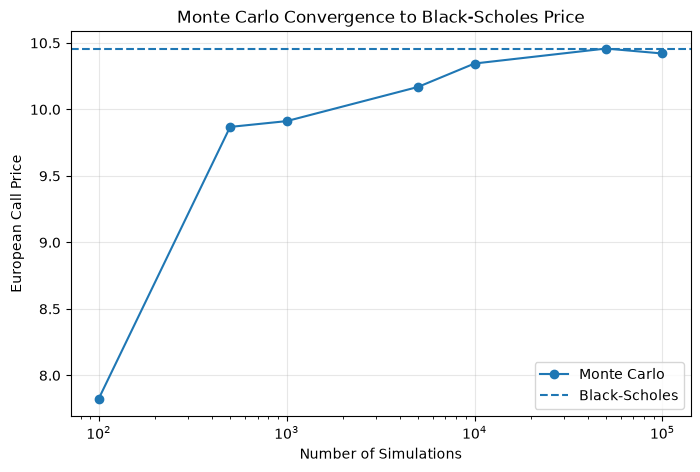

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    path_counts,
    mc_prices,
    marker="o",
    label="Monte Carlo",
)

plt.axhline(
    bs_price,
    linestyle="--",
    label="Black-Scholes",
)

plt.xscale("log")

plt.xlabel("Number of Simulations")
plt.ylabel("European Call Price")
plt.title("Monte Carlo Convergence to Black-Scholes Price")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    figure_dir / "mc_convergence.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 5. Variance Reduction with Antithetic Variates

Monte Carlo simulation can be computationally expensive because its standard error decreases only at the rate

$$
SE
\propto
\frac{1}{\sqrt{N}}
$$

A simple variance-reduction technique is the use of **antithetic variates**.

If

$$
Z
\sim
N(0,1)
$$

then

$$
-Z
\sim
N(0,1)
$$

Therefore, for every simulated random variable $Z_i$, we can simultaneously use its antithetic counterpart $-Z_i$.

The two terminal stock prices are generated using

$$
S_T^{(+)}
=
S_0
\exp
\left[
\left(
r-\frac{1}{2}\sigma^2
\right)T
+
\sigma\sqrt{T}Z
\right]
$$

and

$$
S_T^{(-)}
=
S_0
\exp
\left[
\left(
r-\frac{1}{2}\sigma^2
\right)T
-
\sigma\sqrt{T}Z
\right]
$$

The paired payoff is then defined as

$$
Y_i
=
\frac{
f(Z_i)+f(-Z_i)
}{2}
$$

where $f(\cdot)$ represents the discounted option payoff.

If the two payoffs are negatively correlated, then

$$
\operatorname{Cov}
\left(
f(Z_i),
f(-Z_i)
\right)
<
0
$$

which reduces the variance of the estimator.

The objective is therefore to achieve

$$
SE_{\mathrm{Antithetic}}
<
SE_{\mathrm{Plain}}
$$

In [22]:
plain_price, plain_se = monte_carlo_price(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    option_type="call",
    n_paths=100_000,
    seed=42,
)

anti_price, anti_se = monte_carlo_price_antithetic(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    option_type="call",
    n_paths=100_000,
    seed=42,
)

print("Plain Monte Carlo")
print("Price:", plain_price)
print("Standard Error:", plain_se)

print()

print("Antithetic Monte Carlo")
print("Price:", anti_price)
print("Standard Error:", anti_se)

print()

print(
    "SE reduction:",
    1 - anti_se / plain_se
)

Plain Monte Carlo
Price: 10.420541193153113
Standard Error: 0.046769902520818175

Antithetic Monte Carlo
Price: 10.467314163207845
Standard Error: 0.03307688091107499

SE reduction: 0.292774217428573


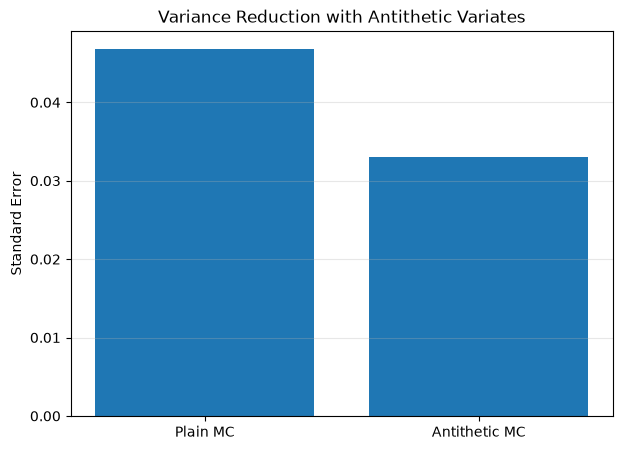

In [23]:
methods = [
    "Plain MC",
    "Antithetic MC",
]

errors = [
    plain_se,
    anti_se,
]

plt.figure(figsize=(7, 5))

plt.bar(
    methods,
    errors,
)

plt.ylabel("Standard Error")
plt.title("Variance Reduction with Antithetic Variates")

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.savefig(
    figure_dir / "variance_reduction.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Conclusion

This notebook implemented Monte Carlo simulation for European option pricing under the risk-neutral geometric Brownian motion model.

The main findings are:

1. Simulated terminal stock prices follow a lognormal distribution.

2. The Monte Carlo estimator produces a European call price close to the Black-Scholes analytical benchmark.

3. The difference between the Monte Carlo estimate and the analytical solution can be interpreted using the standard error and confidence interval.

4. Increasing the number of simulated paths improves the stability of the estimator.

5. Monte Carlo convergence is relatively slow because

$$
SE
\propto
\frac{1}{\sqrt{N}}
$$

6. Antithetic variates can reduce estimator variance by pairing each normal random variable $Z$ with its counterpart $-Z$.

Overall, the experiment demonstrates how numerical simulation can be used to approximate derivative prices when analytical solutions are unavailable or difficult to obtain.